[3.77687444 2.09523736 2.03483821 1.90051764 1.38308634 1.1406069
 0.9836131 ]
[2.06740706 1.40510572 1.13601516 1.09304286 0.99435148 0.98416906
 0.97687695]


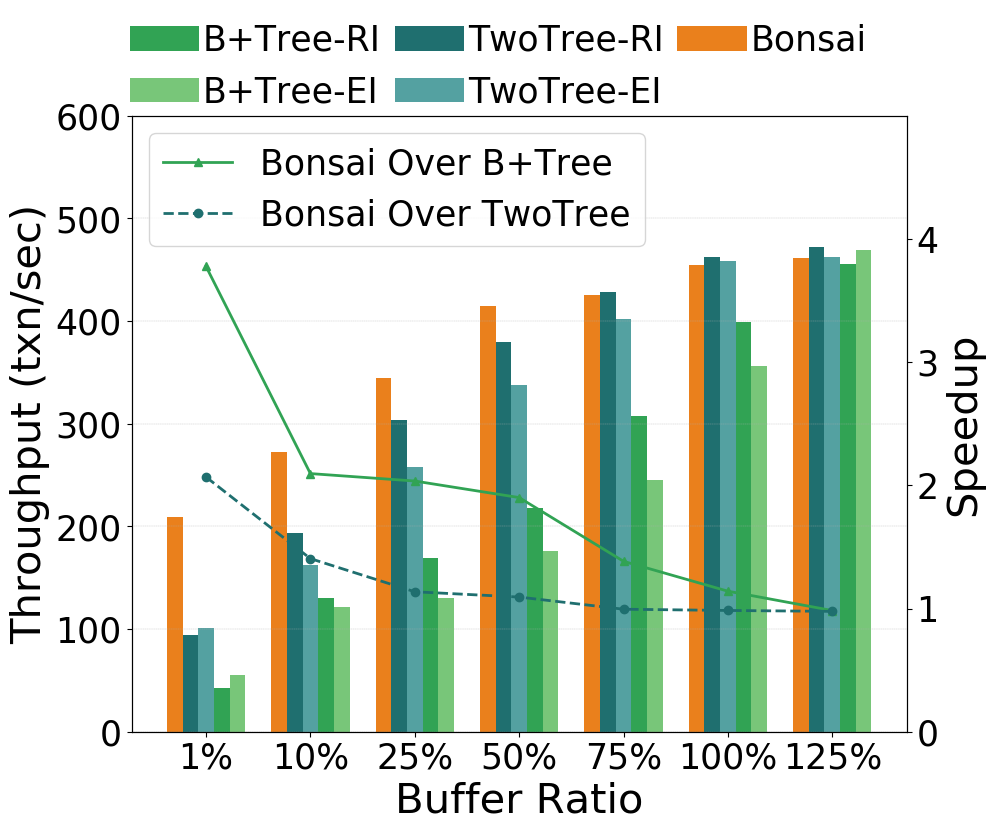

In [9]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

txtsize=30
ticksize=25

color_indices, line_colors = select_color_idx(4)
bonsai_c = "#ea801c"
page_retain_c = "#31a354"
# page_retain_c = line_colors["BLUE"]
page_evict_c = "#78c679"
tt_retain_c = "#1f6f6f"
tt_evict_c = "#54a1a1"

bonsai_label = "Bonsai"
page_idx_label = "B+Tree-RI"
page_idx_evict_label = "B+Tree-EI" 
tt_idx_label = "TwoTree-RI"
tt_idx_evict_label = "TwoTree-EI"

datadir = "../../output/"
exp_page = "exp_point_10g_page_varybuf_rw"
exp_page_idx_evict = "exp_point_10g_page_varybuf_idx_evict_rw"
exp_tuple = "exp_point_10g_tuple_varybuf_rw"
exp_twotree = "exp_point_10g_twotree_varybuf_rw"
exp_twotree_idx_evict = "exp_point_10g_twotree_varybuf_idx_evict_rw"

# exp_page = "exp_point_10g_page_varybuf"
# exp_page_idx_evict = "exp_point_10g_page_varybuf_idx_evict"
# exp_tuple = "exp_point_10g_tuple_varybuf"
# exp_twotree = "exp_point_10g_twotree_varybuf"
# exp_twotree_idx_evict = "exp_point_10g_twotree_varybuf_idx_evict"

# Load and prepare the data
data_page = [json.loads(line) for line in open(datadir + exp_page + ".txt")]
df_page = pd.DataFrame().from_records(data_page).sort_values(by='g_total_buf_sz')

data_page_idx_evict = [json.loads(line) for line in open(datadir + exp_page_idx_evict + ".txt")]
df_page_idx_evict = pd.DataFrame().from_records(data_page_idx_evict).sort_values(by='g_total_buf_sz')

data_tuple = [json.loads(line) for line in open(datadir + exp_tuple + ".txt")]
df_tuple = pd.DataFrame().from_records(data_tuple).sort_values(by='g_total_buf_sz')

data_tt = [json.loads(line) for line in open(datadir + exp_twotree + ".txt")]
df_tt = pd.DataFrame().from_records(data_tt).sort_values(by='g_total_buf_sz')

data_tt_idx_evict = [json.loads(line) for line in open(datadir + exp_twotree_idx_evict + ".txt")]
df_tt_idx_evict = pd.DataFrame().from_records(data_tt_idx_evict)
df_tt_idx_evict = df_tt_idx_evict.sort_values(by='g_total_buf_sz')


fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(df_page))
offset = bar_width

# Bar chart for the primary data
ax1.bar(indices + offset, df_page["throughput_txn_per_sec"], bar_width, label=page_idx_label, color=page_retain_c)
ax1.bar(indices + offset * 2, df_page_idx_evict["throughput_txn_per_sec"], bar_width, label=page_idx_evict_label, color=page_evict_c)
ax1.bar(indices - offset, df_tt["throughput_txn_per_sec"], bar_width, label=tt_idx_label, color=tt_retain_c)
ax1.bar(indices , df_tt_idx_evict["throughput_txn_per_sec"], bar_width, label=tt_idx_evict_label, color=tt_evict_c)
ax1.bar(indices - offset * 2, df_tuple["throughput_txn_per_sec"], bar_width, label=bonsai_label, color=bonsai_c)

ax1.set_xticks(indices)
x_tick_num = np.round(df_page["g_total_buf_sz"] * 100 / (12 * 1000 * 1000 * 1000), 2).astype(int)
x_tick_labels = [f"{num}%" for num in x_tick_num]

ax1.set_xticklabels(x_tick_labels, fontsize=ticksize)
# ax1.set_yticklabels(fontsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_ylim(50, 200000)
ax1.set_ylim(0, 600)

ax1.set_ylabel("Throughput (txn/sec)", fontsize=txtsize)
ax1.set_xlabel("Buffer Ratio", fontsize=txtsize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)

legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(-0.02, 1.07, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# Secondary y-axis for Bonsai's speedup calculation
ax2 = ax1.twinx()

# Calculate speedup of Bonsai over Page-IdxRetain and TwoTree-IdxRetain
page_tps = np.maximum(np.array(df_page["throughput_txn_per_sec"]), np.array(df_page_idx_evict["throughput_txn_per_sec"]))
tt_tps =np.maximum(np.array(df_tt["throughput_txn_per_sec"]), np.array(df_tt_idx_evict["throughput_txn_per_sec"])) 
# print(page_tps)
# print(tt_tps)
# print(df_tuple["throughput_txn_per_sec"] )
speedup_page = np.array(df_tuple["throughput_txn_per_sec"]) / page_tps
speedup_tt = np.array(df_tuple["throughput_txn_per_sec"]) / tt_tps
# print(df_page["throughput_txn_per_sec"])
# print(page_tps)
print(speedup_page)
print(speedup_tt)

# Plot speedup as a line chart on the secondary y-axis
ax2.plot(indices, speedup_page, color=page_retain_c, marker='^', label='Bonsai Over B+Tree', linewidth=2)
ax2.plot(indices, speedup_tt, color=tt_retain_c, marker='o', label='Bonsai Over TwoTree', linestyle='dashed', linewidth=2)

ax2.set_ylabel('Speedup', fontsize=txtsize)
# ax2.set_yscale('log')
ymax = 5
ax2.set_yticks(np.arange(0,ymax, 1))
ax2.set_ylim(0, ymax)
# ax2.set_yticks(np.arange(0, 25, 2))
ax2.set_yticklabels(np.arange(0, ymax, 1), fontsize=ticksize)
ax2.legend(loc='upper left', fontsize=ticksize)


# Legend
# ax1.legend(loc='upper left')

plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-rw-tps-bars-speedup.pdf", bbox_inches='tight')




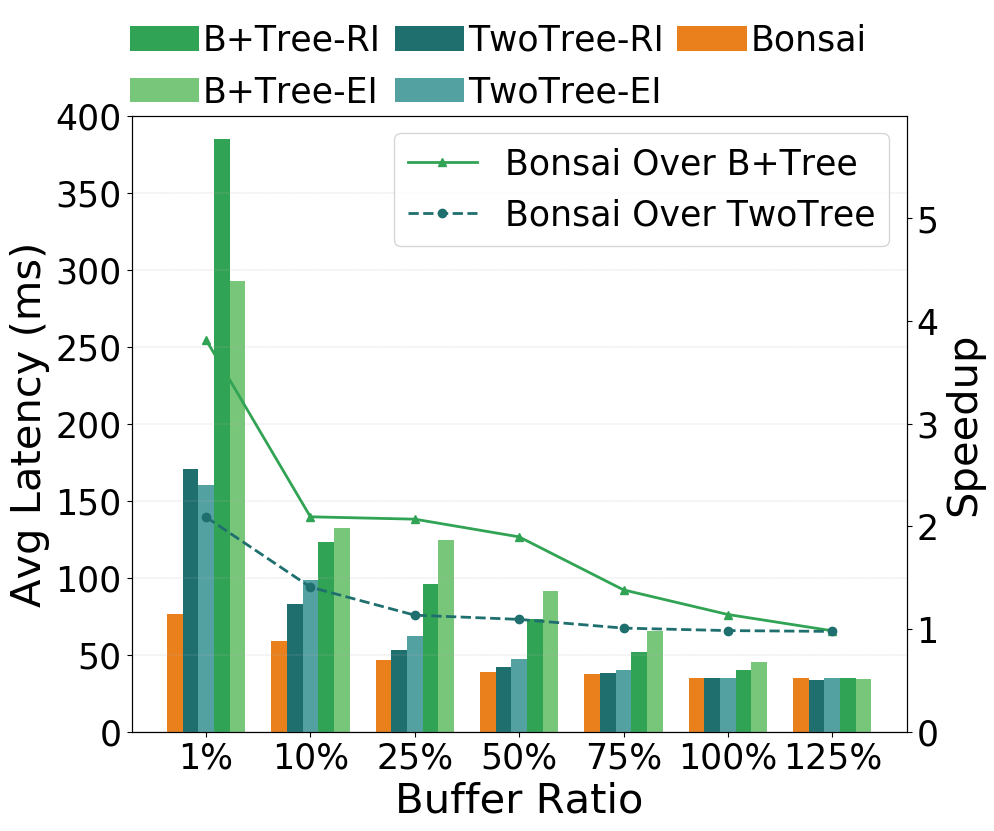

In [10]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx

color_indices, line_colors = select_color_idx(4)
bonsai_c = "#ea801c"
page_retain_c = "#31a354"
# page_retain_c = line_colors["BLUE"]
page_evict_c = "#78c679"
tt_retain_c = "#1f6f6f"
tt_evict_c = "#54a1a1"

datadir = "../../output/"
exp_page = "exp_point_10g_page_varybuf_rw"
exp_page_idx_evict = "exp_point_10g_page_varybuf_idx_evict_rw"
exp_tuple = "exp_point_10g_tuple_varybuf_rw"
exp_twotree = "exp_point_10g_twotree_varybuf_rw"
exp_twotree_idx_evict = "exp_point_10g_twotree_varybuf_idx_evict_rw"

# Load and prepare the data
data_page = [json.loads(line) for line in open(datadir + exp_page + ".txt")]
df_page = pd.DataFrame().from_records(data_page).sort_values(by='g_total_buf_sz')

data_page_idx_evict = [json.loads(line) for line in open(datadir + exp_page_idx_evict + ".txt")]
df_page_idx_evict = pd.DataFrame().from_records(data_page_idx_evict).sort_values(by='g_total_buf_sz')

data_tuple = [json.loads(line) for line in open(datadir + exp_tuple + ".txt")]
df_tuple = pd.DataFrame().from_records(data_tuple).sort_values(by='g_total_buf_sz')

data_tt = [json.loads(line) for line in open(datadir + exp_twotree + ".txt")]
df_tt = pd.DataFrame().from_records(data_tt).sort_values(by='g_total_buf_sz')

data_tt_idx_evict = [json.loads(line) for line in open(datadir + exp_twotree_idx_evict + ".txt")]
df_tt_idx_evict = pd.DataFrame().from_records(data_tt_idx_evict)
df_tt_idx_evict = df_tt_idx_evict.sort_values(by='g_total_buf_sz')

dimension = "avg_sum_txn_latency (us)"

fig, ax1 = plt.subplots(figsize=(10, 8))

bar_width = 0.15
indices = np.arange(len(df_page))
offset = bar_width

# Bar chart for the primary data
ax1.bar(indices + offset, df_page[dimension]/1000.0, bar_width, label=page_idx_label, color=page_retain_c)
ax1.bar(indices + offset * 2, df_page_idx_evict[dimension]/1000.0, bar_width, label=page_idx_evict_label, color=page_evict_c)
ax1.bar(indices - offset, df_tt[dimension]/1000.0, bar_width, label=tt_idx_label, color=tt_retain_c)
ax1.bar(indices , df_tt_idx_evict[dimension]/1000.0, bar_width, label=tt_idx_evict_label, color=tt_evict_c)
ax1.bar(indices - offset * 2, df_tuple[dimension]/1000.0, bar_width, label=bonsai_label, color=bonsai_c)


ax1.set_xticks(indices)
x_tick_num = np.round(df_page["g_total_buf_sz"] * 100 / (12 * 1000 * 1000 * 1000), 2).astype(int)
x_tick_labels = [f"{num}%" for num in x_tick_num]

ax1.set_xticklabels(x_tick_labels, fontsize=ticksize)
# ax1.set_xscale('log')
# ax1.set_yscale('log')
ax1.tick_params(axis='y', labelsize=ticksize)
ax1.set_ylim(0, 400)
ax1.set_ylabel("Avg Latency (ms)", fontsize=txtsize)
ax1.set_xlabel("Buffer Ratio", fontsize=txtsize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)
legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(-0.02, 1.07, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)

# Secondary y-axis for Bonsai's speedup calculation
ax2 = ax1.twinx()

# Calculate speedup of Bonsai over Page-IdxRetain and TwoTree-IdxRetain
page_tps = np.minimum(np.array(df_page[dimension]), np.array(df_page_idx_evict[dimension]))
tt_tps =np.minimum(np.array(df_tt[dimension]), np.array(df_tt_idx_evict[dimension])) 
# print(page_tps)
# print(tt_tps)
# print(df_tuple["throughput_txn_per_sec"] )
speedup_page = page_tps / np.array(df_tuple[dimension]) 
speedup_tt = tt_tps / np.array(df_tuple[dimension]) 
# print(df_page["throughput_txn_per_sec"])
# print(page_tps)
# print(speedup_page)
# print(speedup_tt)

# Plot speedup as a line chart on the secondary y-axis
ax2.plot(indices, speedup_page, color=page_retain_c, marker='^', label='Bonsai Over B+Tree', linewidth=2)
ax2.plot(indices, speedup_tt, color=tt_retain_c, marker='o', label='Bonsai Over TwoTree', linestyle='dashed', linewidth=2)

ax2.set_ylabel('Speedup', fontsize=txtsize)
# ax2.set_yscale('log')
ymax = 6
ax2.set_yticks(np.arange(0,ymax, 1))
ax2.set_ylim(0, ymax)
# ax2.set_yticks(np.arange(0, 25, 2))
ax2.set_yticklabels(np.arange(0, ymax, 1), fontsize=ticksize)
ax2.legend(loc='upper right', fontsize=ticksize)

# Legend
# ax1.legend(loc='upper left')

plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-rw-latency-bars-speedup.pdf", bbox_inches='tight')


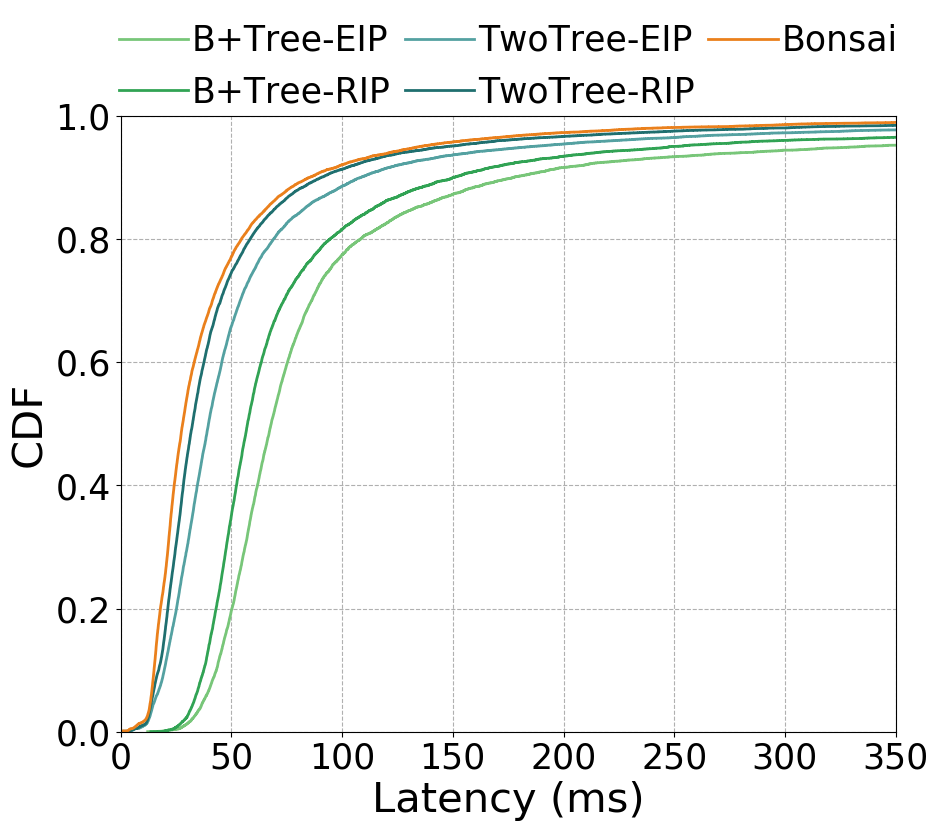

In [24]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import *

datadir = "../../output/"
# test = "exp_point_10g_tuple_varybuf_rw_debug"
test = "exp_point_cdf"

# Load and prepare the data
cdf_data = [json.loads(line) for line in open(datadir + test + ".txt")]
df_data = pd.DataFrame().from_records(cdf_data)
df_data = apply_mask(df_data, [
    ["read_perc_", ["eq", 0.8]]
]) 
cdf_tuple = apply_mask(df_data, [
    ["g_buf_type", ["eq", "OBJBUF"]]
])
cdf_page = apply_mask(df_data, [
    ["g_buf_type", ["eq", "PGBUF"]]
]) 
cdf_page_idx = apply_mask(cdf_page, [
    ["g_retain_idx_page", ["eq", "True"]]
]) 
cdf_page_idx_evict = apply_mask(cdf_page, [
    ["g_retain_idx_page", ["eq", "False"]]
]) 

cdf_tt = apply_mask(df_data, [
    ["g_buf_type", ["eq", "HYBRBUF"]]
]) 
cdf_tt_idx = apply_mask(cdf_tt, [
    ["g_retain_idx_page", ["eq", "True"]]
]) 
cdf_tt_idx_evict = apply_mask(cdf_tt, [
    ["g_retain_idx_page", ["eq", "False"]]
]) 


# Assuming 'txn_latency_dist_ms' contains latency values
latency_data_tuple = np.array(cdf_tuple["txn_latency_dist_ms"].iloc[0]) 
latency_data_page = np.array(cdf_page_idx["txn_latency_dist_ms"].iloc[0])  
latency_data_page_evict = np.array(cdf_page_idx_evict["txn_latency_dist_ms"].iloc[0])  
latency_data_tt = np.array(cdf_tt_idx["txn_latency_dist_ms"].iloc[0])  
latency_data_tt_evict = np.array(cdf_tt_idx_evict["txn_latency_dist_ms"].iloc[0]) 


cutoff_percentile = 99
cutoff_value_tuple = np.percentile(latency_data_tuple, cutoff_percentile)
cutoff_value_page = np.percentile(latency_data_page, cutoff_percentile)
cutoff_value_page_evict = np.percentile(latency_data_page_evict, cutoff_percentile)
cutoff_value_tt = np.percentile(latency_data_tt, cutoff_percentile)
cutoff_value_tt_evict = np.percentile(latency_data_tt_evict, cutoff_percentile)
# print(cutoff_value_tuple)
cutoff_value = min([cutoff_value_tuple, cutoff_value_page, cutoff_value_page_evict,cutoff_value_tt, cutoff_value_tt_evict])
# Filter the data to exclude values beyond the cutoff
# Sort the data for the CDF
sorted_latency_tuple = np.sort(latency_data_tuple[latency_data_tuple <= cutoff_value])
sorted_latency_page = np.sort(latency_data_page[latency_data_page <= cutoff_value])
sorted_latency_page_evict = np.sort(latency_data_page_evict[latency_data_page_evict <= cutoff_value])
sorted_latency_tt = np.sort(latency_data_tt[latency_data_tt <= cutoff_value])
sorted_latency_tt_evict = np.sort(latency_data_tt_evict[latency_data_tt_evict <= cutoff_value])

# Plot the CDF
plt.figure(figsize=(10, 8))
# plt.step(sorted_latency_tuple, np.arange(1, len(sorted_latency_tuple) + 1) * 1.0 / len(latency_data_tuple), where='mid', linestyle='-', color=bonsai_c, label='Bonsai')
line_width= 2
plt.step(sorted_latency_page_evict, np.arange(1, len(sorted_latency_page_evict) + 1) / len(latency_data_page_evict), where='mid', linestyle='-', linewidth=line_width, color=page_evict_c, label=page_idx_evict_label)
plt.step(sorted_latency_page, np.arange(1, len(sorted_latency_page) + 1) / len(latency_data_page), where='mid', linestyle='-', linewidth=line_width, color=page_retain_c, label=page_idx_label)
plt.step(sorted_latency_tt_evict, np.arange(1, len(sorted_latency_tt_evict) + 1) / len(latency_data_tt_evict), where='mid', linestyle='-', linewidth=line_width, color=tt_evict_c, label=tt_idx_evict_label)
plt.step(sorted_latency_tt, np.arange(1, len(sorted_latency_tt) + 1) / len(latency_data_tt), where='mid', linestyle='-', linewidth=line_width, color=tt_retain_c, label=tt_idx_label)
plt.step(sorted_latency_tuple, np.arange(1, len(sorted_latency_tuple) + 1) / len(latency_data_tuple), where='mid', linestyle='-', linewidth=line_width, color=bonsai_c, label=bonsai_label)
# # plt.axvline(p99_latency, color='r', linestyle='--', label=f'99th percentile ({p99_latency:.2f} ms)')
# # plt.axvline(avg_latency, color='g', linestyle='--', label=f'Average ({avg_latency:.2f} ms)')
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)
# legend = plt.legend(fontsize=ticksize, bbox_to_anchor=(-0.02, 1.07, 1.1, .102), loc=2,
#            ncol=3,borderaxespad=0., frameon=False,columnspacing=0.8, handletextpad=0.3)
legend = plt.legend(fontsize=ticksize, bbox_to_anchor=(-0.02, 1.07, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# plt.title('CDF of Transaction Latency')
plt.xlabel('Latency (ms)', fontsize=txtsize)
plt.ylabel('CDF', fontsize= txtsize)
plt.xlim(0, 350) 
plt.ylim(0, 1.0) 
# plt.legend()
plt.grid(True, linestyle = '--')
plt.tick_params(axis='both', labelsize=ticksize)

plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-rw-latency-cdf.pdf",bbox_inches='tight')

plt.show()





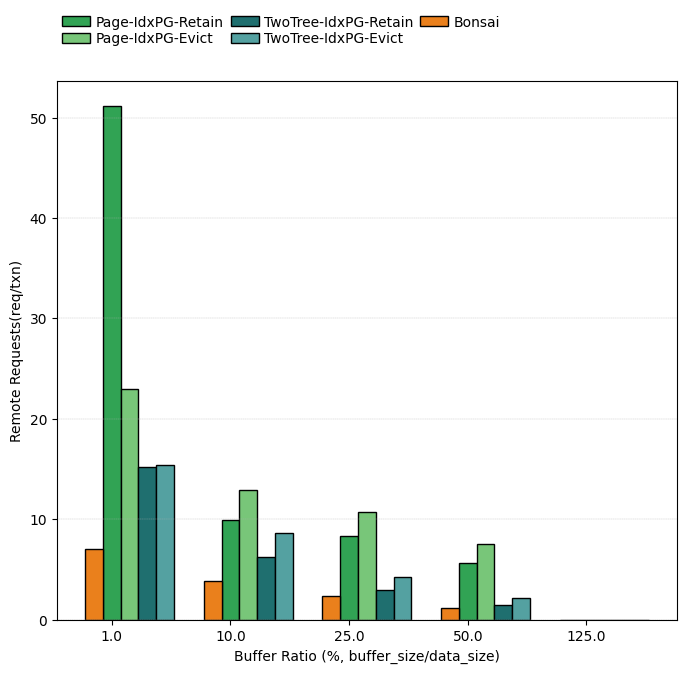

In [26]:


fig = plt.figure(figsize=(8, 7))


index = np.arange(len(df_tuple["g_total_buf_sz"]))

bar_width = 0.15

# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(1, 1, 1)




ax1.bar(index + 2 * bar_width, 
        df_page["misses_"]/df_page["txn_cnt_"], bar_width, edgecolor='black',
        color=page_retain_c,
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        df_page_idx_evict["misses_"]/df_page_idx_evict["txn_cnt_"], bar_width,edgecolor='black',
        color=page_evict_c,
        label="Page-IdxPG-Evict")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        df_tt["misses_"]/df_tt["txn_cnt_"], bar_width,edgecolor='black',
        color=tt_retain_c,
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        df_tt_idx_evict["misses_"]/df_tt_idx_evict["txn_cnt_"],bar_width,edgecolor='black',
        color=tt_evict_c,
        label="TwoTree-IdxPG-Evict")
ax1.bar(index + 1 * bar_width, 
        df_tuple["misses_"]/df_tuple["txn_cnt_"] , bar_width,edgecolor='black',
        color=bonsai_c,
        label="Bonsai")

plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# location = "upper left"
location = "best"
# ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Remote Requests(req/txn)")
ax1.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax1.set_xscale('log')
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)

legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-rw-analysis-remote-reqs-num.pdf",bbox_inches='tight')

# ax1.set_title("Remote Requests Varying Buffer Size (theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
# fig1.set_size_inches(8, 6)
# fig.set_size_inches(8, 6)



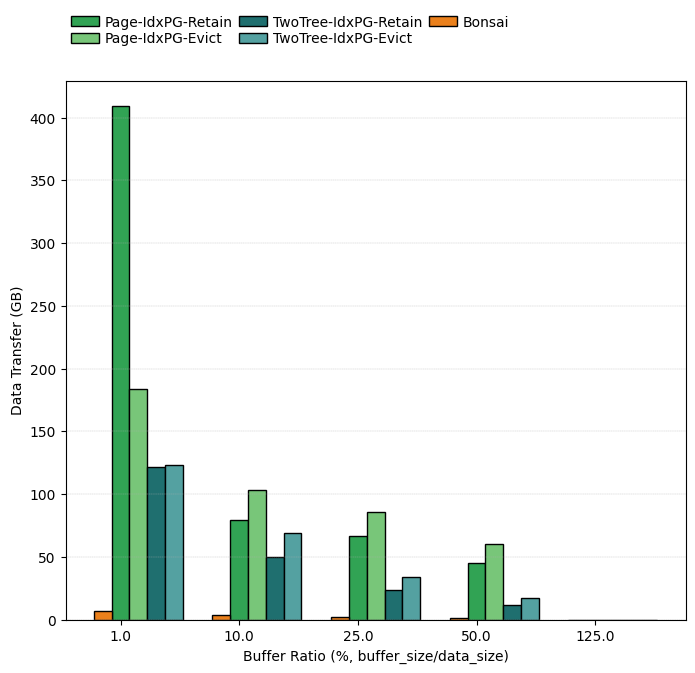

In [29]:
fig = plt.figure(figsize=(8, 7))

ax1 = fig.add_subplot(1, 1, 1)



ax1.bar(index + 2 * bar_width, 
        (df_page["misses_"])*8/df_page["txn_cnt_"], bar_width, edgecolor='black',
        color=page_retain_c,
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        (df_page_idx_evict["misses_"])*8/df_page_idx_evict["txn_cnt_"], bar_width,edgecolor='black',
        color=page_evict_c,
        label="Page-IdxPG-Evict")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        (df_tt["misses_"])*8/df_tt["txn_cnt_"], bar_width,edgecolor='black',
        color=tt_retain_c,
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        (df_tt_idx_evict["misses_"])*8/df_tt_idx_evict["txn_cnt_"],bar_width,edgecolor='black',
        color=tt_evict_c,
        label="TwoTree-IdxPG-Evict")
ax1.bar(index + 1 * bar_width, 
        (df_tuple["misses_"])/df_tuple["txn_cnt_"], bar_width,edgecolor='black',
        color=bonsai_c,
        label="Bonsai")

plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Data Transfer (GB)")
ax1.set_xlabel("Buffer Ratio (%, buffer_size/data_size)")
# ax1.set_yscale('log')

# ax1.set_xscale('log')
# ax1.set_title("Data Transfer Varying Buffer Size (theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-rw-analysis-data-transfer.pdf",bbox_inches='tight')


/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


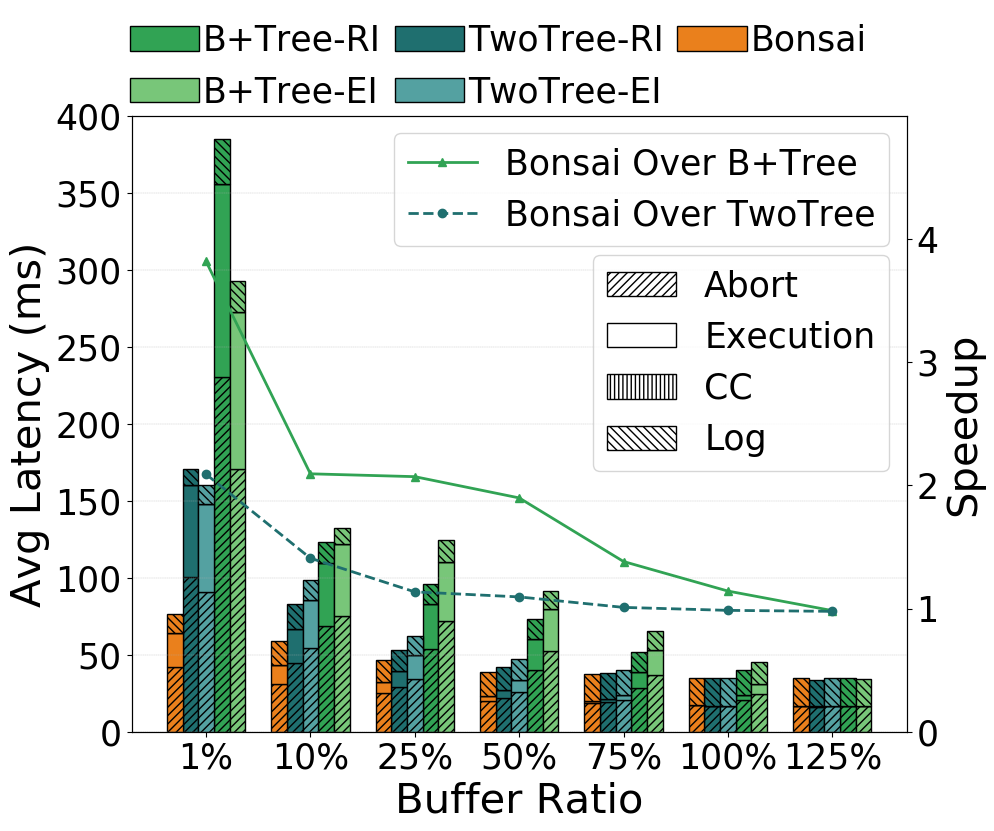

In [14]:
from matplotlib.patches import Patch
# fig, ax1 = plt.subplots(figsize=(12, 9.6))
fig, ax1 = plt.subplots(figsize=(10, 8))
bar_width = 0.15
offset = bar_width
# ax1 = fig.add_subplot(1, 1, 1)
index = np.arange(len(df_tuple["g_total_buf_sz"])) - offset * 3
indices = np.arange(len(df_page))
dimension = "avg_sum_txn_latency (us)"
cur_label="Page"
cur_color=page_retain_c
cur_df = df_page 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 2
barloc = indices + offset

ax1.bar(barloc, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(barloc, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(barloc, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(barloc, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")

cur_label="Page"
cur_color=page_evict_c
cur_df = df_page_idx_evict 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 3
barloc = indices + offset * 2

ax1.bar(barloc, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(barloc, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(barloc, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(barloc, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")

cur_label="TwoTree"
cur_color=tt_retain_c
cur_df = df_tt 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 4
barloc = indices - offset

ax1.bar(barloc, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(barloc, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(barloc, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(barloc, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")


cur_label="TwoTree"
cur_color=tt_evict_c
cur_df = df_tt_idx_evict
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 5
barloc = indices
ax1.bar(barloc, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(barloc, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(barloc, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(barloc, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")

cur_label="Bonsai"
cur_color=bonsai_c
cur_df = df_tuple 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 1
barloc = indices - offset * 2
ax1.bar(barloc, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(barloc, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(barloc, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(barloc, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")

# plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# location = "upper left"
location = "best"
# ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Avg Latency (ms)", fontsize=txtsize)
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax1.set_xlabel("Buffer Ratio", fontsize=txtsize)
ax1.set_xticks(indices)
x_tick_num = np.round(df_page["g_total_buf_sz"] * 100 / (12 * 1000 * 1000 * 1000), 2).astype(int)
x_tick_labels = [f"{num}%" for num in x_tick_num]

ax1.set_xticklabels(x_tick_labels, fontsize=ticksize)
# ax1.set_xscale('log')
# ax1.set_yscale('log')
ax1.tick_params(axis='both', labelsize=ticksize)

subcategories = ['Abort', 'Execution', 'CC', 'Log']  # Stacks within each bar
bar_labels = [ page_idx_label, page_idx_evict_label, tt_idx_label, tt_idx_evict_label,bonsai_label]  # Bars within each group


# Colors for the bars (categories)
colors = [page_retain_c, page_evict_c, tt_retain_c, tt_evict_c,bonsai_c]

# Hatches for the subcategories
hatches = ['////', '', '||||', '\\\\\\\\']

# Create custom patches for the subcategories
hatch_patches = [Patch(facecolor='white', edgecolor='black', hatch=h, label=sc)
                 for h, sc in zip(hatches, subcategories)]

# Create custom patches for the categories
color_patches = [Patch(facecolor=c, edgecolor='black', label=bl)
                 for c, bl in zip(colors, bar_labels)]
ax1.set_ylim(0, 400)

# Create legends
subcat_legend = plt.legend(handles=hatch_patches,fontsize=ticksize, bbox_to_anchor=(-0.1, 0.7, 1.1, .102))
ax1.add_artist(subcat_legend)  # Add the first legend manually to keep it when adding the second
# plt.legend(handles=color_patches, bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
#            ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
legend = plt.legend(handles=color_patches, fontsize=ticksize, bbox_to_anchor=(-0.02, 1.07, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)
# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
#            ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)


# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)



# Secondary y-axis for Bonsai's speedup calculation
ax2 = ax1.twinx()

# Calculate speedup of Bonsai over Page-IdxRetain and TwoTree-IdxRetain
page_tps = np.minimum(df_page[dimension], df_page_idx_evict[dimension])
tt_tps =np.minimum(df_tt[dimension], df_tt_idx_evict[dimension]) 

speedup_page = page_tps/ df_tuple[dimension] 
speedup_tt = tt_tps/ df_tuple[dimension] 
# print(df_page["throughput_txn_per_sec"])
# print(page_tps)

# Plot speedup as a line chart on the secondary y-axis
ax2.plot(indices, speedup_page, color=page_retain_c, marker='^', label='Bonsai Over B+Tree', linewidth=2)
ax2.plot(indices, speedup_tt, color=tt_retain_c, marker='o', label='Bonsai Over TwoTree', linestyle='dashed', linewidth=2)

ax2.set_ylabel('Speedup')
# ax2.set_yscale('log')
ax2.set_yticks(np.arange(0, 8, 2))
ax2.set_ylim(0, 4)
ax2.legend(loc='upper right', fontsize=ticksize)

ymax = 5
ax2.set_ylabel('Speedup', fontsize=txtsize)
# ax2.set_yscale('log')
ax2.set_yticks(np.arange(0, ymax, 1))
ax2.set_yticklabels(np.arange(0, ymax, 1), fontsize=ticksize)
ax2.set_ylim(0, ymax)

# Legend
# ax1.legend(loc='upper left')

plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-rw-latency-bars-speedup-breakdown.pdf", bbox_inches='tight')
